In [12]:
!pip install --upgrade tensorflow keras
import pandas as pd
from matplotlib import pyplot as plt
import numpy as np
import seaborn as sn
import tensorflow as tf
import keras as kr
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import confusion_matrix, classification_report
%matplotlib inline

In [2]:
df = pd.read_csv("9) churn_modelling.csv")
df.sample(5)

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
5134,5135,15641604,Frolova,850,France,Female,55,10,98488.08,1,1,0,155879.57,1
7673,7674,15788634,Romani,750,Spain,Female,37,2,113817.06,1,0,0,88333.74,0
1141,1142,15716134,Russo,617,France,Male,40,5,190008.32,2,1,1,107047.92,0
1416,1417,15667651,Young,585,Spain,Female,33,8,0.00,2,1,0,114182.07,0
4004,4005,15738546,Gboliwe,530,Spain,Female,41,4,0.00,2,0,1,147606.71,0


In [3]:
df.drop(df[["CustomerId", "Surname", "RowNumber"]],axis='columns',inplace=True)
df.dtypes

,0
CreditScore,int64
Geography,object
Gender,object
Age,int64
Tenure,int64
Balance,float64
NumOfProducts,int64
HasCrCard,int64
IsActiveMember,int64
EstimatedSalary,float64


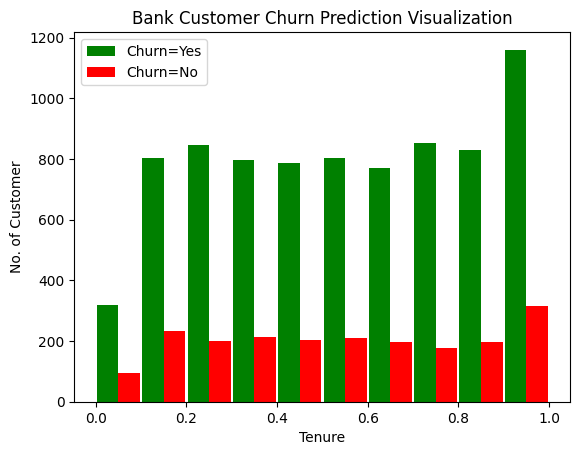

In [31]:
plt.xlabel("Tenure")
plt.ylabel("No. of Customer")
plt.title("Bank Customer Churn Prediction Visualization")
plt.hist([df[df.Exited == 0].Tenure, df[df.Exited == 1].Tenure], rwidth=0.95, color=["green","red"], label=["Churn=Yes", "Churn=No"])
plt.legend()

In [5]:
def print_unique_col_values(df):
       for column in df:
            if df[column].dtypes=='object':
                print(f'{column}: {df[column].unique()}')
print_unique_col_values(df)

Geography: ['France' 'Spain' 'Germany']
Gender: ['Female' 'Male']


In [6]:
df = pd.get_dummies(data=df, columns=['Geography','Gender'])
df = df.astype(int)
print(df.columns, "\\n\n\n")
df.sample(5)

Index(['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard',
       'IsActiveMember', 'EstimatedSalary', 'Exited', 'Geography_France',
       'Geography_Germany', 'Geography_Spain', 'Gender_Female', 'Gender_Male'],
      dtype='object') \n




,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_France,Geography_Germany,Geography_Spain,Gender_Female,Gender_Male
7241,521,37,5,105843,2,1,1,84908,0,1,0,0,0,1
5169,651,31,7,138008,2,1,0,129912,0,0,1,0,0,1
4600,574,34,5,112324,2,1,1,17993,0,1,0,0,1,0
6870,850,36,0,136980,2,1,1,99019,0,0,1,0,1,0
6327,667,36,3,121542,2,1,1,186841,0,0,0,1,1,0


In [7]:
scaler = MinMaxScaler()
cols = ["CreditScore","Age","Tenure","Balance","NumOfProducts","EstimatedSalary"]
df[cols] = scaler.fit_transform(df[cols])

In [8]:
x = df.drop('Exited',axis='columns')
y = df['Exited']
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.2,random_state=5)
print(x_train.shape, x_test.shape, y_train.shape, y_test.shape)

(8000, 13) (2000, 13) (8000,) (2000,)


In [9]:
model = kr.Sequential()
model.add(kr.layers.Dense(6, input_shape=(13,), activation='relu'))
model.add(kr.layers.Dense(8, activation='relu'))
model.add(kr.layers.Dense(1, activation='sigmoid'))
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
model.summary()

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 6)              │            84 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │            56 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 149 (596.00 B)

 Trainable params: 149 (596.00 B)

 Non-trainable params: 0 (0.00 B)

In [10]:
model.fit(x_train, y_train, epochs=10)

Epoch 1/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.4583 - loss: 0.7205
Epoch 2/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7983 - loss: 0.5257
Epoch 3/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7927 - loss: 0.4858
Epoch 4/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7935 - loss: 0.4749
Epoch 5/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8063 - loss: 0.4561
Epoch 6/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8136 - loss: 0.4323
Epoch 7/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.8193 - loss: 0.4157
Epoch 8/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.8281 - loss: 0.3933
Epoch 9/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8369 - loss: 0.3799
Epoch 10/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8355 - loss: 0.3775


In [13]:
yp = model.predict(x_test)
y_pred = []
for i in yp:
  if i > 0.5:
    y_pred.append(1)
  else:
    y_pred.append(0)

print(classification_report(y_test,y_pred))

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
              precision    recall  f1-score   support

           0       0.86      0.95      0.91      1595
           1       0.69      0.41      0.51       405

    accuracy                           0.84      2000
   macro avg       0.78      0.68      0.71      2000
weighted avg       0.83      0.84      0.83      2000



Text(95.72222222222221, 0.5, 'Truth')

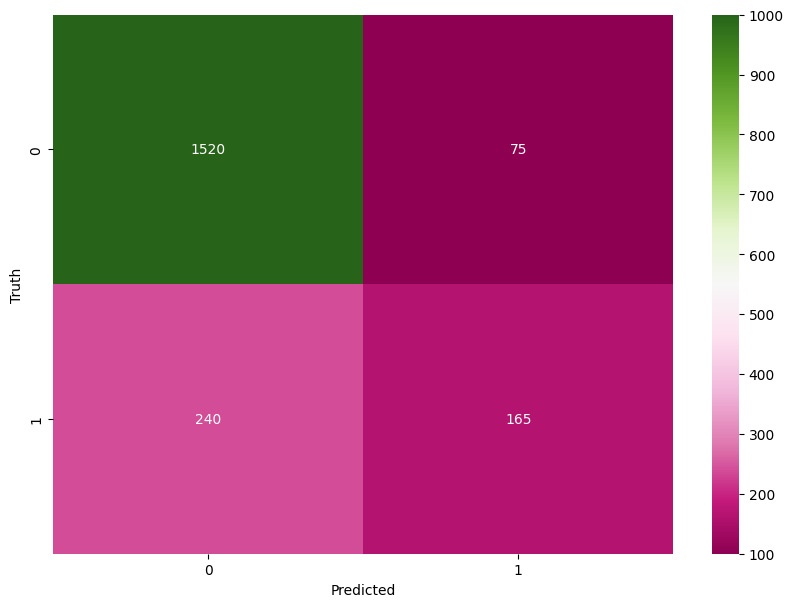

In [35]:
cm = tf.math.confusion_matrix(labels=y_test,predictions=y_pred)
plt.figure(figsize = (10,7))
sn.heatmap(cm, annot=True, fmt='d', cmap="PiYG", vmin = 100, vmax = 1000)
plt.xlabel('Predicted')
plt.ylabel('Truth')